In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score,  mean_squared_error

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import KFold, GridSearchCV
from scipy.optimize import minimize 

### AI MENTION

The most repeated AI use can be seen for the plotting and printing of results for a pleasing and comprehensive representation.

# Ordinary Least Squares (OLS) Regression

## <span style="color:red">NOTES</span> 

Brief explanation of what we are doing for future me:

The regression model is trying to find the relationship between our $X$ matrix and your $Y$ matrix in the format of $Y= w * X$. Because we defined $X = t^2$ our model is trying to find $Y= w * t^2$ and as we know in the theoretical formula, our model will try to find $w$ which is $w = \frac{1}{2} * g$.

We aim for a w such that:

$$
\hat{w}_{OLS}=\left(X^T X\right)^{-1} X^T y
$$

NOTE (WHY WE ARE USING THIS FORMULAS):

Both OLS and Ridge use squared values ($w^2$).If you graph $y=x^2$, it forms a smooth "U" shape (a parabola).The bottom of that "U" is perfectly flat. The derivative (the slope) is exactly 0. Because the math is smooth and continuous, mathematicians were able to create a single, clean matrix formula to jump straight to that bottom point: w = inv(X.T @ X) @ X.T @ Y. This is called a closed-form solution.

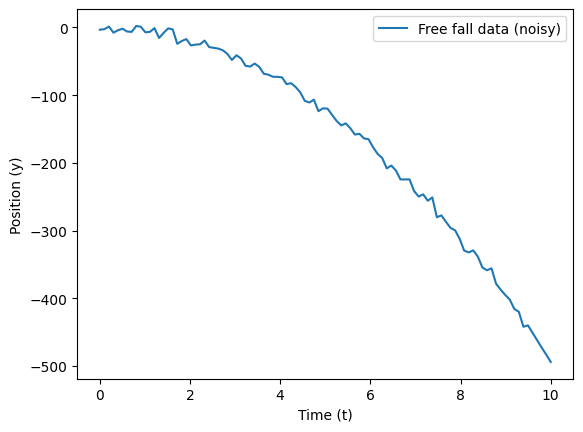

--- OLS REGRESSION RESULTS ---
Calculated w_ols: -4.8938
Expected theoretical value (1/2 * g): -4.9
R-squared Score: 0.9989


In [49]:
#Parameters
g = -9.8
sigma = 5
N = 100 # Number of data points

# Generate data
t = np.linspace (0 , 10 , N )
noise = np.random.normal (0 , sigma , N )

#Function
y = 0.5 * g * t**2 + noise

#Plotting
plt.plot(t, y, label="Free fall data (noisy)")
plt.xlabel("Time (t)")
plt.ylabel("Position (y)")
plt.legend()
plt.show()

#We transform into matrices
X_mat = np.array(t**2)

Y_mat = np.array(y)

#We turn the matrices into columns so we can operate with them

X = X_mat.reshape(-1,1)

Y = Y_mat.reshape(-1,1)

### ORDINARY LEAST SQUARES METHOD

#THETA_OLS VALUES
w = np.linalg.inv(X.T @ X)

w_ols = w @ X.T @ Y #Result from here will be shown like this [[-4.90324156]]

print("--- OLS REGRESSION RESULTS ---")
print(f"Calculated w_ols: {w_ols[0][0]:.4f}") #Reason why we use [0][0]
#Because we used matrix multiplication (@) to calculate w_ols, 
#NumPy strictly keeps the result as a 2D matrix, even if it only contains a single number.
#:.4f = give me only 4 decimals of my result
print(f"Expected theoretical value (1/2 * g): {0.5 * g}")

#R^2 coefficient
y_pred = X @ w_ols # Generating our model's predictions
r2 = r2_score(Y, y_pred) # Comparing predictions to actual noisy data
print(f"R-squared Score: {r2:.4f}")

### CODE MADE WITH THE HELP OF AI TO SEE THE EFFECTS OF DIFFERENT SIGMAS

Across the activity we will use this body to study the effect of the regression models


--- OLS REGRESSION RESULTS ---
Sigma | Calculated w_ols | R-squared Score
---------------------------------------------
  1   |     -4.9009      |     1.0000
  6   |     -4.8993      |     0.9985
 15   |     -4.8944      |     0.9882
 25   |     -4.8505      |     0.9781
 45   |     -4.9605      |     0.9072
 65   |     -4.9232      |     0.8450
 80   |     -4.9393      |     0.7628
 100   |     -4.7655      |     0.6692
 170   |     -3.8256      |     0.3659


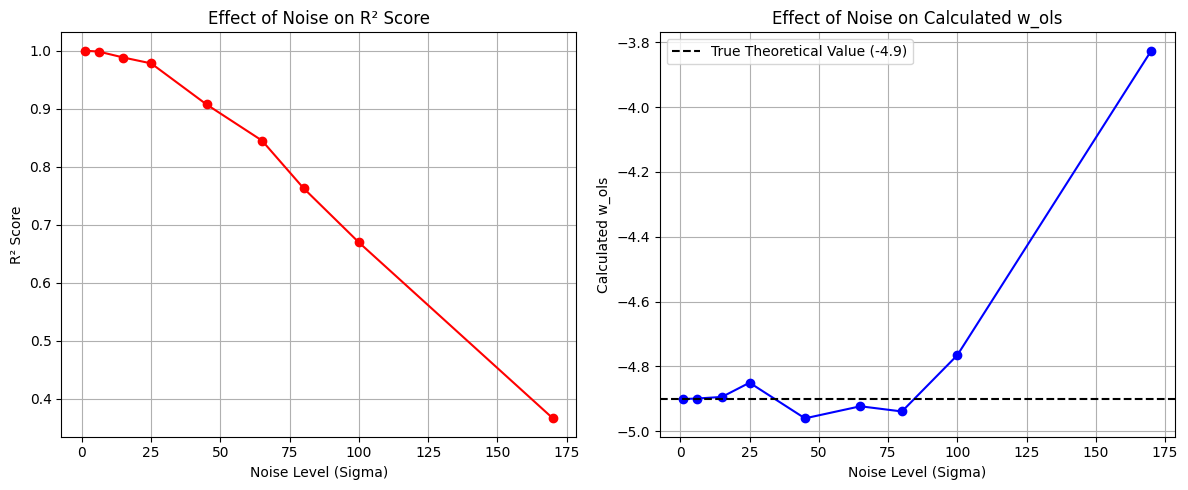

In [ ]:
# Parameters
g = -9.8
sigmas =[1, 6, 15, 25, 45, 65, 80, 100, 170] 
N = 100 

#We start the generation of sigmas and linespace on the same seed for the models so we can compare them.
np.random.seed(42)

t = np.linspace(0, 10, N)
X_mat = np.array(t**2)
X = X_mat.reshape(-1, 1)

# Pre-calculate the (X.T @ X)^-1 part of OLS (since X never changes)
w = np.linalg.inv(X.T @ X)

# We will create empty lists to save our results for the final plot
w_ols_results = []
r2_results =[]

print("--- OLS REGRESSION RESULTS ---")
print("Sigma | Calculated w_ols | R-squared Score")
print("-" * 45)

# ---------------------------------------------------------
# THE LOOP: We run the simulation once for every sigma
# ---------------------------------------------------------
for sigma in sigmas:
    
    noise = np.random.normal(0, sigma, N)
    y = 0.5 * g * t**2 + noise
    Y = y.reshape(-1, 1)
    
    # 2. Calculate OLS
    w_ols = w @ X.T @ Y 
    w_ols_value = w_ols[0][0] # We slect the [0][0] because we don't want a 2D matrix we want a value
    w_ols_results.append(w_ols_value) # Save it to our list
    
    # 3. Calculate R^2
    y_pred = X @ w_ols
    r2 = r2_score(Y, y_pred)
    r2_results.append(r2) # Save it to our list
    
    # Print the results nicely formatted
    print(f" {sigma:2d}   |     {w_ols_value:.4f}      |     {r2:.4f}")

# ---------------------------------------------------------
# PLOTTING HOW NOISE AFFECTS THE MODEL
# ---------------------------------------------------------
# We create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: How noise affects the R^2 score
ax1.plot(sigmas, r2_results, marker='o', color='red') #Marker = o adds the dots 
ax1.set_title("Effect of Noise on R² Score")
ax1.set_xlabel("Noise Level (Sigma)")
ax1.set_ylabel("R² Score")
ax1.grid(True)

# Plot 2: How noise affects the calculated w_ols
ax2.plot(sigmas, w_ols_results, marker='o', color='blue')
ax2.axhline(y=0.5*g, color='black', linestyle='--', label="True Theoretical Value (-4.9)")
ax2.set_title("Effect of Noise on Calculated w_ols")
ax2.set_xlabel("Noise Level (Sigma)")
ax2.set_ylabel("Calculated w_ols")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Result Analysis

Explaining the different R^2 values (variance):

$w_{ols}$ measures the average direction of the data, while $R^2$ measures the spread (or messiness) of the data.

It is entirely possible to have a line that points in the exact right direction ($w_{ols}$ near -4.9) but is surrounded by an absolute chaotic mess of data points (terrible $R^2$).

Imagine two people throwing 100 darts at a target:

- Player A (Sigma = 65): Throws a very tight cluster of darts, but the cluster is slightly up and to the left of the bullseye.

- Player B (Sigma = 170): Throws darts wildly all over the entire wall. However, by pure luck, the darts hit symmetrically—some way up, some way down, some way left, some way right. If you average out the position of all those wild darts, the exact center is right on the bullseye.

In this analogy:

The center of the cluster is your $w_{ols}$​ (how close it is to -4.9). The tightness of the cluster is your $R^2$.

Summary:

$w_{ols}$ is highly dependent on the "balance" of the random noise. Sometimes, even with huge noise, it cancels out perfectly and gives you a accurate $w_{ols}$ by pure luck.

$R^2$ doesn't care about luck. It is purely a measure of noise. As sigma strictly goes up, the data strictly gets messier, $R^2$  and will strictly go down, regardless of where the center of the line ends up.

This also proves that our OLS model will have a high Variance and zero Bias.

### Conclusions:

OLS has major drawbacks. First, OLS has **no mechanism to filter out noise variables**. Second, it assumes that **factor loadings are constant over time**. In practice, we will generally have many variables that you would like to filter down. We must remember that the OLS doesn't has a way to differentiate between noise and datapoints so it will try to adjust to everything, thus creating overfitting.

# RIDGE REGRESSION 

We will now use the same body of the code but change the machine for the ridge method in which we will have to add our lambda factor.

We aim for:

$$
\hat{\mathbf{w}}_{\text {Ridge }}=\left(\mathbf{X}^T \mathbf{X}+\lambda \mathbf{I}\right)^{-1} \mathbf{X}^T \mathbf{y}
$$

--- RIDGE REGRESSION RESULTS ---
Lambda | Calculated w_ridge | R-squared Score
-----------------------------------------------
    0  |       -5.0576      |     0.4417
    1  |       -5.0576      |     0.4417
   10  |       -5.0574      |     0.4417
   50  |       -5.0564      |     0.4417
  100  |       -5.0551      |     0.4417
  500  |       -5.0452      |     0.4417
 1000  |       -5.0328      |     0.4417
 5000  |       -4.9361      |     0.4410


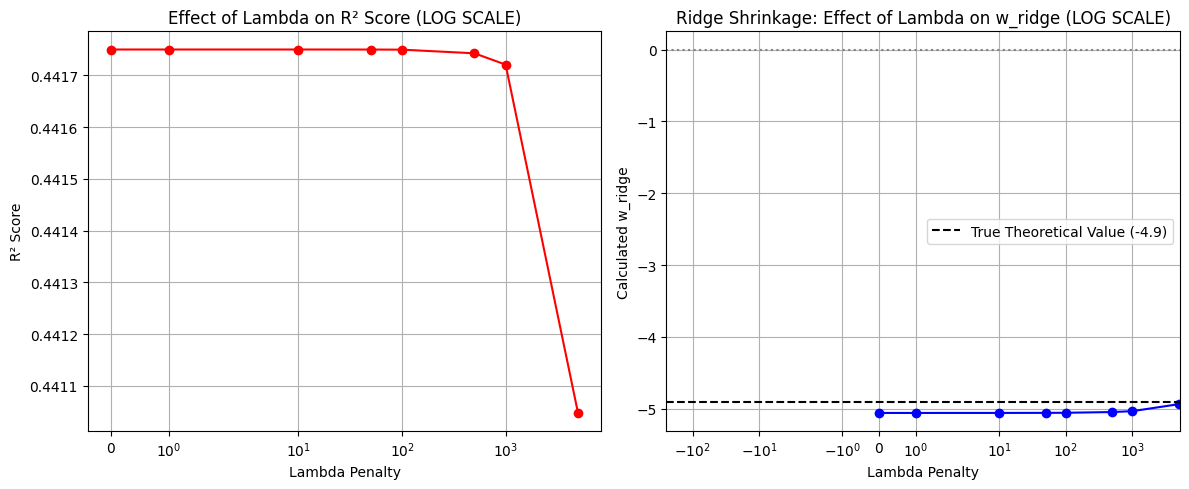

In [52]:
# parameters
g = -9.8
sigma = 170 # We keep noise constant to see only the effect of Lambda
N = 100 
lambdas =[0, 1, 10, 50, 100, 500, 1000, 5000] 
np.random.seed(42)

#Data generation
t = np.linspace(0, 10, N)
noise = np.random.normal(0, sigma, N)
y = 0.5 * g * t**2 + noise

X_mat = np.array(t**2)
X = X_mat.reshape(-1, 1)
Y = y.reshape(-1, 1)

# Create the Identity Matrix (1x1 because we only have 1 feature: t^2)
I = np.eye(X.shape[1]) 

# Empty lists to save our results
w_ridge_results = []
r2_results =[]

print("--- RIDGE REGRESSION RESULTS ---")
print("Lambda | Calculated w_ridge | R-squared Score")
print("-" * 47)

# ---------------------------------------------------------
# THE LOOP: We run the math once for every Lambda
# ---------------------------------------------------------
for Lambda in lambdas:
    
    #Ridge body
    w_matrix = np.linalg.inv(X.T @ X + Lambda * I)
    
    
    w_ridge = w_matrix @ X.T @ Y 
    w_ridge_value = w_ridge[0][0] 
    w_ridge_results.append(w_ridge_value) 
    
    # Calculate R^2
    y_pred = X @ w_ridge
    r2 = r2_score(Y, y_pred)
    r2_results.append(r2) 
    
    # Print the results
    print(f" {Lambda:4d}  |      {w_ridge_value:8.4f}      |     {r2:.4f}")

# ---------------------------------------------------------
# PLOTTING HOW LAMBDA AFFECTS THE MODEL
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: How Lambda affects the R^2 score
ax1.plot(lambdas, r2_results, marker='o', color='red')
ax1.set_title("Effect of Lambda on R² Score (LOG SCALE)")
ax1.set_xlabel("Lambda Penalty")
ax1.set_ylabel("R² Score")
ax1.set_xscale('symlog') # We use log scale because Lambdas get very big
ax1.grid(True)

# Plot 2: How Lambda "shrinks" the calculated w_ridge
ax2.plot(lambdas, w_ridge_results, marker='o', color='blue')
ax2.axhline(y=0.5*g, color='black', linestyle='--', label="True Theoretical Value (-4.9)")
ax2.axhline(y=0, color='gray', linestyle=':') # The zero line
ax2.set_title("Ridge Shrinkage: Effect of Lambda on w_ridge (LOG SCALE)")
ax2.set_xlabel("Lambda Penalty")
ax2.set_ylabel("Calculated w_ridge")
ax2.set_xscale('symlog') # We use log scale because Lambdas get very big
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## $\sigma = 65$

--- RIDGE REGRESSION RESULTS ---
Lambda | Calculated w_ridge | R-squared Score
-----------------------------------------------
    0  |       -4.9603      |     0.8561
    1  |       -4.9602      |     0.8561
   10  |       -4.9600      |     0.8561
   50  |       -4.9591      |     0.8561
  100  |       -4.9578      |     0.8561
  500  |       -4.9481      |     0.8561
 1000  |       -4.9360      |     0.8560
 5000  |       -4.8411      |     0.8549


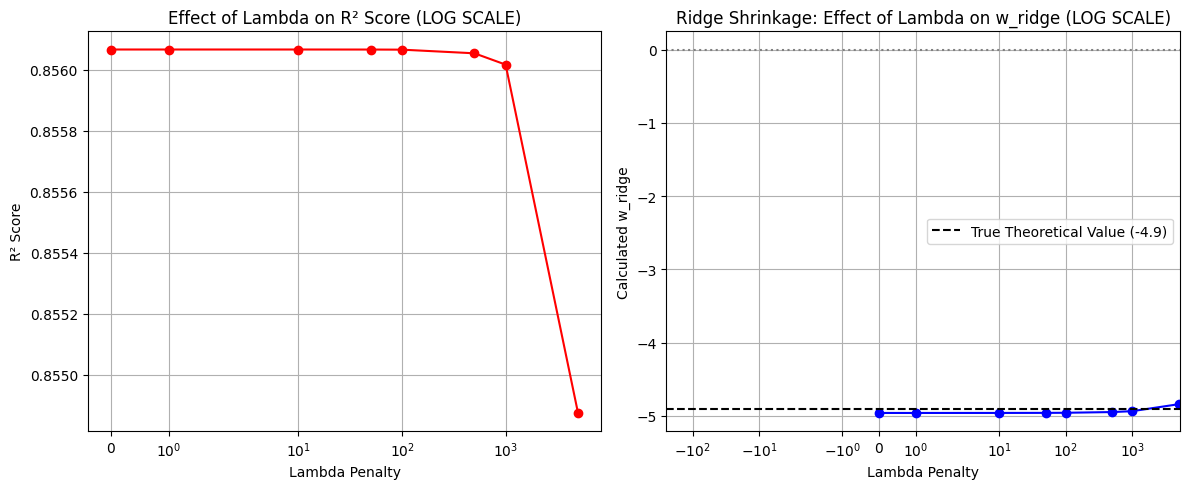

In [ ]:
#Parameters
g = -9.8
sigma = 65 # We keep noise constant to see only the effect of Lambda
N = 100 
lambdas =[0, 1, 10, 50, 100, 500, 1000, 5000] 
np.random.seed(42)

#Data generation
t = np.linspace(0, 10, N)
noise = np.random.normal(0, sigma, N)
y = 0.5 * g * t**2 + noise

X_mat = np.array(t**2)
X = X_mat.reshape(-1, 1)
Y = y.reshape(-1, 1)

# Create the Identity Matrix (1x1 because we only have 1 feature: t^2)
I = np.eye(X.shape[1]) 

# Empty lists to save our results
w_ridge_results = []
r2_results =[]

print("--- RIDGE REGRESSION RESULTS ---")
print("Lambda | Calculated w_ridge | R-squared Score")
print("-" * 47)

# ---------------------------------------------------------
# THE LOOP: We run the math once for every Lambda
# ---------------------------------------------------------
for Lambda in lambdas:
    
    #Ridge body
    w_matrix = np.linalg.inv(X.T @ X + Lambda * I)
    
    
    w_ridge = w_matrix @ X.T @ Y 
    w_ridge_value = w_ridge[0][0] 
    w_ridge_results.append(w_ridge_value) # Save it
    
    # Calculate R^2
    y_pred = X @ w_ridge
    r2 = r2_score(Y, y_pred)
    r2_results.append(r2) # Save it
    
    # Print the results
    print(f" {Lambda:4d}  |      {w_ridge_value:8.4f}      |     {r2:.4f}")

# ---------------------------------------------------------
# PLOTTING HOW LAMBDA AFFECTS THE MODEL
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: How Lambda affects the R^2 score
ax1.plot(lambdas, r2_results, marker='o', color='red')
ax1.set_title("Effect of Lambda on R² Score (LOG SCALE)")
ax1.set_xlabel("Lambda Penalty")
ax1.set_ylabel("R² Score")
ax1.set_xscale('symlog') # We use log scale because Lambdas get very big
ax1.grid(True)

# Plot 2: How Lambda "shrinks" the calculated w_ridge
ax2.plot(lambdas, w_ridge_results, marker='o', color='blue')
ax2.axhline(y=0.5*g, color='black', linestyle='--', label="True Theoretical Value (-4.9)")
ax2.axhline(y=0, color='gray', linestyle=':') # The zero line
ax2.set_title("Ridge Shrinkage: Effect of Lambda on w_ridge (LOG SCALE)")
ax2.set_xlabel("Lambda Penalty")
ax2.set_ylabel("Calculated w_ridge")
ax2.set_xscale('symlog') # We use log scale because Lambdas get very big
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Result Analysis (RIDGE)

Instead of guessing -4.90, Ridge might guess -4.80 or -4.60 (depending on how large we set $\lambda$). By adding bias (pulling the weight towards zero), Ridge makes the model slightly less accurate on the training data, but it prevents the line from reacting too aggressively to extreme noise. We may have now reduced the overfitting issue.

As we said this happens because of the introduction of Bias via $\lambda$ since it will try to pull the coefficients weight to zero in order to avoid high variance and overfitting. Studying lambda we can see that for $\lambda=0$ the $w$ and $R^2$ are quite similar almost identical to the OLS results we saw before. For the increasing Lambdas we observe low variance of $R^2$ and a slight loss of precision in our $w$ prediction.

As Lambda gets bigger (moving right on the graph), we visually see the blue line being "pulled" upwards, away from the true physics value (-4.9) and aggressively towards 0. This is the core mathematical behavior of Ridge Regression: it shrinks coefficients to zero.

As the penalty gets massive (like Lambda = 5000), the model is essentially forced to guess $w \approx 0$. Because a flat line of $y=0$ is a terrible way to predict a falling object, $R^2$ your score will plummet.

### Conclusion

After analyzing our results we can conclude that while Ridge deals better with noise by introducing Bias, high levels of Bias may bring us to underfitting reaching inaccurate predictions of our $w$ (-4.9). This whole analysis was made with a $\sigma = 170$ so we can compare with the results where the OLS performs poorly and see how Ridge obtains more accurate $w$ and higher $R^2$.

Still when we compare OLS to Ridge with lower Sigmas like $\sigma = 65$ we can see that OLS is more accurate in the prediction of $w$ (it's closer to -4.9) but has lower $R^2$ values (more variance).

# LASSO REGRESSION

As always we will use a similar body and we aim for:

$$
\hat{\mathbf{w}}_{\mathrm{LASSO}}=\arg \min _{\mathbf{w} \in \mathbb{R}^p}\left(|\mathbf{X} \mathbf{w}-\mathbf{y}|_2^2+\lambda|\mathbf{w}|_1\right)
$$

Before writing the code, there is one mathematical difference we need to know, LASSO does not have a simple matrix formula. LASSO formula includes the absolute value of the weights ($|w|$). Because you cannot easily calculate the mathematical derivative of an absolute value (it creates a sharp "V" shape at zero), there is no single equation to solve it. Hence we will use the Scikit library.

--- LASSO REGRESSION RESULTS ---
Lambda | Calculated w_lasso | R-squared Score
-----------------------------------------------
    0.1 |       -5.0576      |     0.4417
    1.0 |       -5.0571      |     0.4417
   10.0 |       -5.0527      |     0.4417
  100.0 |       -5.0084      |     0.4416
  500.0 |       -4.8114      |     0.4389
 1000.0 |       -4.5651      |     0.4302
 2500.0 |       -3.8263      |     0.3697


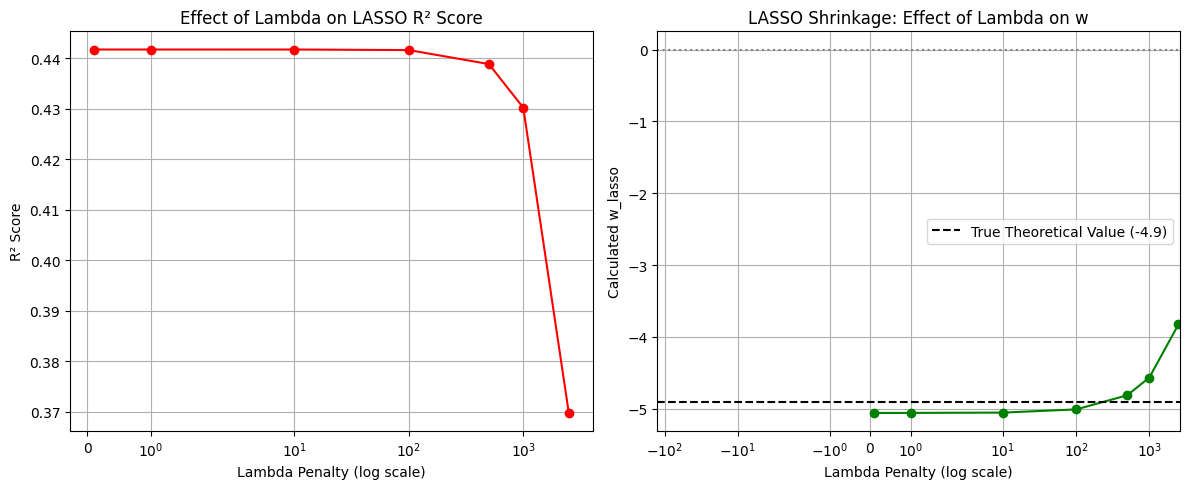

In [48]:
#Parameters
g = -9.8
sigma = 170
N = 100 
# (Note: scikit-learn calls this parameter 'alpha' instead of 'lambda')
lambdas =[0.1, 1, 10, 100, 500, 1000, 2500] 
np.random.seed(42) 

#Generate Dataset
t = np.linspace(0, 10, N)
noise = np.random.normal(0, sigma, N)
y = 0.5 * g * t**2 + noise

# Transform into matrices
X = (t**2).reshape(-1, 1)
Y = y.reshape(-1, 1)


# Empty lists to save our results
w_lasso_results =[]
r2_results =[]

print("--- LASSO REGRESSION RESULTS ---")
print("Lambda | Calculated w_lasso | R-squared Score")
print("-" * 47)

# ---------------------------------------------------------
# THE LOOP: We train a new LASSO model for every Lambda
# ---------------------------------------------------------
for Lambda in lambdas:
    
    # Create the LASSO model. 
    # We set fit_intercept=False because our physics formula (y = w*t^2) 
    # assumes the object starts at 0, just like our OLS/Ridge math did.
    model = Lasso(alpha=Lambda, fit_intercept=False)
    
    # Train (fit) the model with coordinate descent
    model.fit(X, Y)
    
    # Extract the calculated weight (w)
    # sklearn stores the coefficients in an array called .coef_
    w_lasso_value = model.coef_[0] 
    w_lasso_results.append(w_lasso_value)
    
    # Predict and calculate R^2
    y_pred = model.predict(X)
    r2 = r2_score(Y, y_pred)
    r2_results.append(r2)
    
    print(f" {Lambda:6.1f} |      {w_lasso_value:8.4f}      |     {r2:.4f}")

# ---------------------------------------------------------
# PLOTTING HOW LAMBDA AFFECTS LASSO
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: R^2 Score
ax1.plot(lambdas, r2_results, marker='o', color='red')
ax1.set_title("Effect of Lambda on LASSO R² Score")
ax1.set_xlabel("Lambda Penalty (log scale)")
ax1.set_ylabel("R² Score")
ax1.set_xscale('symlog') 
ax1.grid(True)

# Plot 2: Shrinkage of w_lasso
ax2.plot(lambdas, w_lasso_results, marker='o', color='green')
ax2.axhline(y=0.5*g, color='black', linestyle='--', label="True Theoretical Value (-4.9)")
ax2.axhline(y=0, color='gray', linestyle=':')
ax2.set_title("LASSO Shrinkage: Effect of Lambda on w")
ax2.set_xlabel("Lambda Penalty (log scale)")
ax2.set_ylabel("Calculated w_lasso")
ax2.set_xscale('symlog')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Result Analysis (LASSO) and comparison with Ridge

Firstly we will compare how each regression model reacts to the different values of lambda. The most noteworthy fact is their behaviors with the highest lambdas:

- Ridge model: Even when we apply a massive penalty of Lambda = 5000, Ridge barely varies numerically. The weight $w$ goes from -5.05 to -4.93. Just a slight adjustment. The blue line looks almost flat.

- Lasso model: With a penalty of one-half (Lambda = 2500), LASSO undergoes severe shrinkage. The weight $w$ is violently dragged from -5.05 to -3.82 (the green curve rises sharply toward zero). If we would had set Lambda = 10000 in LASSO, the green line would have touched exactly 0.

The mathematical reason for this is that in this problem the X values are time squared ($t^2$). Since $t$ goes up to 10, ($t^2$) reaches 100. In the Ridge matrix $(\left(\mathbf{X}^T \mathbf{X}+\lambda \mathbf{I}\right)^{-1})$ , the value of $(\mathbf{X}^T \mathbf{X})$ is a huge number (the sum of all the $t^4$ terms). Therefore, adding a lambda of 5,000 is peanuts for the matrix. For Ridge to collapse here, we would need a lambda of 100,000 or more. LASSO, due to its Absolute Value ($w_1$) nature, tackles the coefficient much more directly.

Turning to the graphs, if we look for both models their effect of lambda in the $R^2$ we may notice that both share similar patterns, but there's a key difference, due to the logarithmic scale the difference between values the fall ridge experiences is not as great as the one that Lasso does.

For Ridge we see the range is from 0.4411 to 0.4417. In other words, the drop is minuscule (a loss of only 0.0007 in R-squared). The model lost almost no predictive power. On the other hand in LASSO, the drop is significant and severe. The Y-axis ranges from 0.37 to 0.44. The R-squared value fell from 0.4417 to 0.3697. Since LASSO drastically reduced the coefficient $w$ bringing it close to zero, the prediction line became much worse.

### Conclusion

From this analysis we may conclude that for this particular problem (where we know that the variable $t^2$ is the only real and true variable that governs the physics of the fall), Ridge is a much better model.

Ridge realizes that $t^2$ is crucial, so it refuses to drop it; it merely adjusts its value slightly to account for noise. LASSO, on the other hand, is an algorithm designed to “drop” variables. Because it penalizes so heavily, it begins to eliminate the only useful variable in your model, causing predictions ($t^2$) to deteriorate rapidly.

# FINDING THE BEST LAMBDA FOR RIDGE AND LASSO

Instead of writing a massive for loop by hand, scikit-learn has built-in tools that do this automatically: RidgeCV and LassoCV (CV stands for Cross-Validation). (I used a bit of help of the AI to understand how to use this new tools.)

In [61]:
g = -9.8
sigma = 170 
N = 100 
np.random.seed(42) 


t = np.linspace(0, 10, N)
noise = np.random.normal(0, sigma, N)
y = 0.5 * g * t**2 + noise

X = (t**2).reshape(-1, 1)
Y = y.reshape(-1, 1)


#SPLIT THE DATA 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# Define a "Grid" of Lambdas to test
# np.logspace(-3, 4, 100) generates 100 numbers from 0.001 up to 10,000
lambda_grid = np.logspace(-3, 4, 100)


# We give RidgeCV our grid of lambdas (sklearn calls it 'alphas')
ridge_cv = RidgeCV(alphas=lambda_grid, fit_intercept=False, cv=5) #cv is the k fold for the lambdas 
ridge_cv.fit(X_train, Y_train)

best_ridge_lambda = ridge_cv.alpha_
print(f"The best Lambda for Ridge is: {best_ridge_lambda:.4f}")



# We do the same for LassoCV
lasso_cv = LassoCV(alphas=lambda_grid, fit_intercept=False, cv=5, random_state=42)
lasso_cv.fit(X_train, Y_train.reshape(-1))

best_lasso_lambda = lasso_cv.alpha_
print(f"The best Lambda for LASSO is: {best_lasso_lambda:.4f}")

The best Lambda for Ridge is: 1417.4742
The best Lambda for LASSO is: 1.0975


# MODEL COMPARISON 

In this section we will split the into training sets and test sets using the Scikit library, for Ridge, Lasso and OLS and test the models for the unseen data.


In [57]:
g = -9.8
sigma = 170 
N = 100 
Lambda = 500 # A strong penalty for Ridge and LASSO
np.random.seed(42) 


t = np.linspace(0, 10, N)
noise = np.random.normal(0, sigma, N)
y = 0.5 * g * t**2 + noise

X = (t**2).reshape(-1, 1)
Y = y.reshape(-1, 1)


#SPLIT THE DATA 
# We use 80% of data to train, 20% to test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#Calculate the R^2 and w.

# --- OLS REGRESSION ---
w_ols = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train
y_pred_ols = X_test @ w_ols  
r2_ols = r2_score(Y_test, y_pred_ols)
mse_ols = mean_squared_error(Y_test, y_pred_ols)

# --- RIDGE REGRESSION ---
I = np.eye(X_train.shape[1])
w_ridge = np.linalg.inv(X_train.T @ X_train + Lambda * I) @ X_train.T @ Y_train
y_pred_ridge = X_test @ w_ridge 
r2_ridge = r2_score(Y_test, y_pred_ridge)
mse_ridge = mean_squared_error(Y_test, y_pred_ridge)

# --- LASSO REGRESSION ---
lasso = Lasso(alpha=Lambda, fit_intercept=False)
lasso.fit(X_train, Y_train)
y_pred_lasso = lasso.predict(X_test).reshape(-1, 1) 
r2_lasso = r2_score(Y_test, y_pred_lasso)
mse_lasso = mean_squared_error(Y_test, y_pred_lasso)


#Results
print("--- FINAL MODEL COMPARISON (TEST DATA) ---")
print(f"True Physics w : {0.5 * g}")
print("-" * 55)
print("Model   | Calculated w | Test R^2 Score | Test MSE Error")
print("-" * 55)
print(f"OLS     |    {w_ols[0][0]:8.4f}  |     {r2_ols:.4f}     |  {mse_ols:.2f}")
print(f"Ridge   |    {w_ridge[0][0]:8.4f}  |     {r2_ridge:.4f}     |  {mse_ridge:.2f}")
print(f"LASSO   |    {lasso.coef_[0]:8.4f}  |     {r2_lasso:.4f}     |  {mse_lasso:.2f}")
print("-" * 55)

--- FINAL MODEL COMPARISON (TEST DATA) ---
True Physics w : -4.9
-------------------------------------------------------
Model   | Calculated w | Test R^2 Score | Test MSE Error
-------------------------------------------------------
OLS     |     -5.1076  |     0.4265     |  18112.31
Ridge   |     -5.0928  |     0.4270     |  18097.65
LASSO   |     -4.8753  |     0.4313     |  17959.91
-------------------------------------------------------


### Result analysis MODEL COMPARISON

This final results are really interesting since they differ quite a bit from the results we had before. Now it seems that for unseen data and with training Lasso is the best fit mode in terms of $R^2$ and $w$. This is the theory of why this happened. 

In the OLS section we previously discussed that it deals horribly with high amounts of noise, in this simulation it's the model with the furthest prediction of $w$. The reason why it's not as low as before when it reached $w = -3.86$ is probably because of the internal calculus of written OLS by hand and using the Scikit library. And the $R^2$ is so low due to overfitting.

Ridge in this case obtained similar values to when we programmed it, little bit higher than the highest one and the $R^2$ is pretty similar also.

Finally LASSO's penalty was more aggressive than Ridge and by shrinking the coefficient, LASSO accidentally landed almost exactly on the true ground-truth physics value of -4.9, because LASSO essentially ignored the training noise and mathematically stumbled onto the true physics equation, it attained better results the other models on the unseen Test Data.